# 10. Feature Selection

## Objective

This notebook evaluates the engineered features and selects the most useful ones for downstream modeling.

It focuses on:
- checking data sanity before selection
- reviewing target relationships and redundancy
- ranking features using multiple selection methods
- creating a final shortlist of keep / review / drop candidates


In [130]:
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectFromModel, mutual_info_classif
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False

project_root = Path.cwd()
if not (project_root / "src").exists() and (project_root.parent / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import RANDOM_STATE, TARGET_COLUMN, TEST_SIZE

sns.set_theme(style="whitegrid")


## Load Feature-Engineered Dataset

Load the feature-engineered dataset from the previous notebook and define `X` and `y`. The numeric `target` column is used as the label for all downstream selection steps.


In [131]:
target_column = "target"
engineered_data_path = project_root / "data" / "processed" / "telco_churn_engineered.csv"

if not engineered_data_path.exists():
    raise FileNotFoundError(
        "Engineered dataset not found. Run notebook 09_feature_engineering.ipynb first "
        f"to create: {engineered_data_path}"
    )

df = pd.read_csv(engineered_data_path)

if target_column not in df.columns:
    raise KeyError(f"{target_column!r} was not found in the engineered dataset.")

X = df.drop(columns=[column for column in [target_column] if column in df.columns])
y = df[target_column].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

dataset_summary = {
    "dataset_source": str(engineered_data_path.relative_to(project_root)),
    "dataset_shape": df.shape,
    "target_column": target_column,
    "X_shape": X.shape,
    "y_shape": y.shape,
    "X_train_shape": X_train.shape,
    "X_test_shape": X_test.shape,
    "y_train_shape": y_train.shape,
    "y_test_shape": y_test.shape,
    "test_size": TEST_SIZE,
}

dataset_summary


{'dataset_source': 'data/processed/telco_churn_engineered.csv',
 'dataset_shape': (7043, 34),
 'target_column': 'target',
 'X_shape': (7043, 33),
 'y_shape': (7043,),
 'X_train_shape': (5634, 33),
 'X_test_shape': (1409, 33),
 'y_train_shape': (5634,),
 'y_test_shape': (1409,),
 'test_size': 0.2}

## Data Sanity Check

Check dataset shape, missing values, dtypes, and duplicate columns before feature selection.


In [132]:
missing_values = X_train.isna().sum().sort_values(ascending=False)
missing_features = missing_values[missing_values > 0]
dtype_summary = X_train.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="feature_count")
duplicate_columns = X_train.columns[X_train.columns.duplicated()].tolist()

sanity_summary = {
    "feature_count": X_train.shape[1],
    "row_count": X_train.shape[0],
    "missing_feature_count": int(missing_features.shape[0]),
    "total_missing_values": int(missing_features.sum()) if not missing_features.empty else 0,
    "duplicate_column_count": len(duplicate_columns),
}

sanity_summary


{'feature_count': 33,
 'row_count': 5634,
 'missing_feature_count': 0,
 'total_missing_values': 0,
 'duplicate_column_count': 0}

## Review Feature Types

Separate the training features into numerical, binary, and encoded categorical groups. Encoded categorical features are converted to dummy columns inside this notebook only for selection methods that require a numeric matrix.


In [133]:
raw_numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
binary_features = [
    column
    for column in raw_numeric_features
    if set(pd.Series(X_train[column]).dropna().astype(float).unique()).issubset({0.0, 1.0})
]
numerical_features = [column for column in raw_numeric_features if column not in binary_features]
encoded_categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

X_train_encoded = pd.get_dummies(X_train, columns=encoded_categorical_features, drop_first=False, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=encoded_categorical_features, drop_first=False, dtype=int)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join="left", axis=1, fill_value=0)

feature_type_map = {}
for feature in numerical_features:
    feature_type_map[feature] = "numerical"
for feature in binary_features:
    feature_type_map[feature] = "binary"
for feature in encoded_categorical_features:
    feature_type_map[feature] = "encoded_categorical"
for feature in X_train_encoded.columns:
    if feature not in feature_type_map:
        parent_feature = next(
            (column for column in encoded_categorical_features if feature.startswith(f"{column}_")),
            None,
        )
        feature_type_map[feature] = "encoded_categorical_dummy" if parent_feature else "derived_numeric"

feature_type_summary = pd.DataFrame(
    {
        "feature_type": ["numerical", "binary", "encoded_categorical"],
        "feature_count": [len(numerical_features), len(binary_features), len(encoded_categorical_features)],
        "features": [
            ", ".join(numerical_features),
            ", ".join(binary_features),
            ", ".join(encoded_categorical_features),
        ],
    }
)

feature_type_summary


,feature_type,feature_count,features
0,numerical,7,"tenure, MonthlyCharges, log_total_charges, Con..."
1,binary,10,"gender, SeniorCitizen, Partner, Dependents, Ph..."
2,encoded_categorical,16,"MultipleLines, InternetService, OnlineSecurity..."


## Remove Low-Information Features

Detect constant and near-constant features from the training matrix only. These are marked for removal before ranking and model-based selection.


In [134]:
raw_numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
binary_features = [
    column
    for column in raw_numeric_features
    if set(pd.Series(X_train[column]).dropna().astype(float).unique()).issubset({0.0, 1.0})
]
numerical_features = [column for column in raw_numeric_features if column not in binary_features]
all_object_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

# Drop original categorical columns only when a dedicated ordinal representation already exists.
redundant_originals = [
    column for column in all_object_features if f"{column}_ordinal" in X_train.columns
]
encoded_categorical_features = [
    column for column in all_object_features if column not in redundant_originals
]

X_train_clean = X_train.drop(columns=redundant_originals, errors="ignore")
X_test_clean = X_test.drop(columns=redundant_originals, errors="ignore")

X_train_encoded = pd.get_dummies(
    X_train_clean, columns=encoded_categorical_features, drop_first=False, dtype=int
)
X_test_encoded = pd.get_dummies(
    X_test_clean, columns=encoded_categorical_features, drop_first=False, dtype=int
)
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join="left", axis=1, fill_value=0
)

feature_type_map = {}
for feature in numerical_features:
    feature_type_map[feature] = "numerical"
for feature in binary_features:
    feature_type_map[feature] = "binary"
for feature in encoded_categorical_features:
    feature_type_map[feature] = "encoded_categorical"
for feature in X_train_encoded.columns:
    if feature not in feature_type_map:
        parent_feature = next(
            (column for column in encoded_categorical_features if feature.startswith(f"{column}_")),
            None,
        )
        feature_type_map[feature] = "encoded_categorical_dummy" if parent_feature else "derived_numeric"

feature_type_summary = pd.DataFrame(
    {
        "feature_type": ["numerical", "binary", "encoded_categorical", "dropped_redundant_originals"],
        "feature_count": [
            len(numerical_features),
            len(binary_features),
            len(encoded_categorical_features),
            len(redundant_originals),
        ],
        "features": [
            ", ".join(numerical_features),
            ", ".join(binary_features),
            ", ".join(encoded_categorical_features),
            ", ".join(redundant_originals),
        ],
    }
)

feature_variance = X_train_encoded.var(numeric_only=True)
constant_features = feature_variance[feature_variance == 0].index.tolist()
near_constant_threshold = 0.01
near_constant_features = feature_variance[
    (feature_variance > 0) & (feature_variance <= near_constant_threshold)
].sort_values().index.tolist()

low_information_features = sorted(set(constant_features + near_constant_features))

X_train_selection = X_train_encoded.drop(columns=constant_features, errors="ignore").copy()
X_test_selection = X_test_encoded.drop(columns=constant_features, errors="ignore").copy()

low_information_summary = {
    "constant_feature_count": len(constant_features),
    "near_constant_feature_count": len(near_constant_features),
    "near_constant_threshold": near_constant_threshold,
    "remaining_feature_count": X_train_selection.shape[1],
}

feature_type_summary


,feature_type,feature_count,features
0,numerical,7,"tenure, MonthlyCharges, log_total_charges, Con..."
1,binary,10,"gender, SeniorCitizen, Partner, Dependents, Ph..."
2,encoded_categorical,15,"MultipleLines, InternetService, OnlineSecurity..."
3,dropped_redundant_originals,1,Contract


The low-information screening now starts from the cleaned feature-engineering output, where binary fields already exist in their final numeric form on the original columns, `customerID` has already been removed, and cumulative charges are represented by `log_total_charges`. That keeps the training matrix compact and leaves this notebook focused on true low-information and redundancy issues rather than schema cleanup.


## Target Relationship Review

Compute correlation with target for numerical and binary features using Pearson and point-biserial correlation.


In [135]:
target_relationship_rows = []
for feature in numerical_features + binary_features:
    if feature not in X_train.columns:
        continue
    series = X_train[feature].astype(float)
    pearson_r = series.corr(y_train)
    point_r, point_p = pointbiserialr(y_train, series)
    target_relationship_rows.append(
        {
            "feature": feature,
            "pearson_target_corr": round(float(pearson_r), 4),
            "abs_pearson_target_corr": round(abs(float(pearson_r)), 4),
            "pointbiserial_r": round(float(point_r), 4),
            "pointbiserial_p_value": float(point_p),
        }
    )

target_relationship_df = pd.DataFrame(target_relationship_rows).sort_values(
    "abs_pearson_target_corr", ascending=False
).reset_index(drop=True)

target_relationship_df.head(15)


,feature,pearson_target_corr,abs_pearson_target_corr,pointbiserial_r,pointbiserial_p_value
0,is_month_to_month,0.4064,0.4064,0.4064,4.455069e-223
1,Contract_ordinal,-0.3973,0.3973,-0.3973,2.311129e-212
2,tenure,-0.3456,0.3456,-0.3456,8.634920e-158
3,is_new_customer,0.3146,0.3146,0.3146,1.210820e-129
4,log_total_charges,-0.2251,0.2251,-0.2251,1.244926e-65
5,is_auto_payment,-0.2189,0.2189,-0.2189,4.549283e-62
6,PaperlessBilling,0.1980,0.1980,0.1980,6.713317e-51
7,MonthlyCharges,0.1980,0.1980,0.1980,6.266598e-51
8,avg_monthly_spend,0.1973,0.1973,0.1973,1.537696e-50
9,tenure_x_MonthlyCharges,-0.1940,0.1940,-0.1940,6.646567e-49


The target relationship review confirms that contract and lifecycle features remain the strongest direct churn signals. `Contract_ordinal` shows a strong negative relationship with churn (`-0.3973`), which means churn decreases as contract commitment increases, while `is_month_to_month` remains one of the strongest positive churn indicators. `tenure` also shows a clear negative association, reinforcing the earlier EDA finding that shorter-tenure customers are more likely to leave.


## Redundancy Review

Compute feature-feature correlation among numerical and binary features to identify highly correlated candidate pairs.


In [136]:
redundancy_features = [feature for feature in numerical_features + binary_features if feature in X_train.columns]
redundancy_corr_matrix = X_train[redundancy_features].astype(float).corr()

high_corr_threshold = 0.8
high_corr_pairs = []
for left_index, left_feature in enumerate(redundancy_corr_matrix.columns):
    for right_feature in redundancy_corr_matrix.columns[left_index + 1 :]:
        corr_value = redundancy_corr_matrix.loc[left_feature, right_feature]
        if abs(corr_value) >= high_corr_threshold:
            high_corr_pairs.append(
                {
                    "feature_1": left_feature,
                    "feature_2": right_feature,
                    "correlation": round(float(corr_value), 4),
                    "abs_correlation": round(abs(float(corr_value)), 4),
                }
            )

high_corr_pairs_df = pd.DataFrame(high_corr_pairs).sort_values(
    "abs_correlation", ascending=False
).reset_index(drop=True) if high_corr_pairs else pd.DataFrame(
    columns=["feature_1", "feature_2", "correlation", "abs_correlation"]
)

high_corr_pairs_df.head(15)


,feature_1,feature_2,correlation,abs_correlation
0,MonthlyCharges,avg_monthly_spend,0.9963,0.9963
1,Contract_ordinal,is_month_to_month,-0.9162,0.9162
2,tenure,log_total_charges,0.8311,0.8311
3,tenure,tenure_x_MonthlyCharges,0.8300,0.8300
4,log_total_charges,tenure_x_MonthlyCharges,0.8275,0.8275


The redundancy review is intended to flag overlapping signals before final feature selection. In this dataset, the main redundancy pattern is expected around lifecycle-related variables such as `tenure`, `log_total_charges`, `avg_monthly_spend`, and `tenure_x_MonthlyCharges`. Even after dropping raw `TotalCharges`, the log-transformed cumulative-charge feature still overlaps materially with tenure and spend-derived features, so these should be reviewed carefully for linear models. A similar issue exists in the contract family: `Contract_ordinal` and `is_month_to_month` capture nearly the same contract-commitment signal, so they should not both be treated as independent final features for linear models. The preferred linear-model representation is `Contract_ordinal`, while `is_month_to_month` is better retained as a business-friendly review feature or optional tree-model signal.


## Mutual Information

Rank the encoded training features by mutual information to capture non-linear relevance with churn.


In [137]:
discrete_mask = np.array([
    feature_type_map.get(feature) in {"binary", "encoded_categorical_dummy"}
    for feature in X_train_selection.columns
])

mi_scores = mutual_info_classif(
    X_train_selection,
    y_train,
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE,
)

mi_df = pd.DataFrame(
    {
        "feature": X_train_selection.columns,
        "mutual_information": np.round(mi_scores, 4),
    }
).sort_values("mutual_information", ascending=False).reset_index(drop=True)

mi_df.head(15)


,feature,mutual_information
0,Contract_ordinal,0.0995
1,is_month_to_month,0.0926
2,tenure,0.0734
3,contract_payment_profile_Month-to-month__Elect...,0.0656
4,OnlineSecurity_No,0.0628
5,internet_onlinesecurity_profile_Fiber optic__No,0.0617
6,TechSupport_No,0.0599
7,internet_techsupport_profile_Fiber optic__No,0.0587
8,tenure_x_MonthlyCharges,0.0517
9,MonthlyCharges,0.0509


The mutual information ranking confirms that contract structure, tenure, and service-support variables remain the strongest predictive signals. `Contract_ordinal`, `is_month_to_month`, and `Contract_Month-to-month` all rank highly, which reinforces the importance of contract commitment but also signals duplication among co-derived contract features. Support-related variables such as `OnlineSecurity_No`, `TechSupport_No`, and fiber-based interaction profiles also score strongly, showing that both service adoption and service-type combinations contribute meaningful non-linear churn signal.


## Tree-Based Feature Importance

Fit a Random Forest model on the training matrix and extract feature importance scores.


In [138]:
rf_selector = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)
rf_selector.fit(X_train_selection, y_train)

rf_importance_df = pd.DataFrame(
    {
        "feature": X_train_selection.columns,
        "tree_importance": np.round(rf_selector.feature_importances_, 6),
    }
).sort_values("tree_importance", ascending=False).reset_index(drop=True)

rf_importance_df.head(15)


,feature,tree_importance
0,log_total_charges,0.085553
1,tenure_x_MonthlyCharges,0.084930
2,avg_monthly_spend,0.079090
3,tenure,0.078348
4,MonthlyCharges,0.076524
5,Contract_ordinal,0.047388
6,is_month_to_month,0.045174
7,OnlineSecurity_No,0.023492
8,TechSupport_No,0.021557
9,contract_payment_profile_Month-to-month__Elect...,0.021535


The tree-based importance ranking shifts more weight toward continuous lifecycle and spend variables than the mutual-information view. `log_total_charges`, `tenure_x_MonthlyCharges`, `avg_monthly_spend`, `MonthlyCharges`, and `tenure` are expected to remain among the stronger continuous signals, which suggests tree models benefit from cumulative value and spending-intensity features. Contract features still remain important, but the tree model appears to extract more value from continuous and interaction-based features than from single categorical flags alone. If `gender` appears near the lower end of the ranking, it should still be interpreted cautiously, because earlier bivariate analysis did not support gender as a strong churn driver and any signal there is likely weak or unstable rather than a reliable primary feature.


## VIF / Multicollinearity Review

Apply VIF to numerical features only. This is most relevant for later linear models.


In [139]:
vif_features = [feature for feature in numerical_features if feature in X_train.columns]
vif_df = pd.DataFrame(columns=["feature", "vif"])
vif_method = "not_computed"

def compute_vif_fallback(vif_input: pd.DataFrame) -> pd.DataFrame:
    vif_rows = []
    for feature in vif_input.columns:
        predictors = vif_input.drop(columns=[feature])
        if predictors.shape[1] == 0:
            vif_value = 1.0
        else:
            target = vif_input[feature]
            reg = LinearRegression()
            reg.fit(predictors, target)
            r_squared = reg.score(predictors, target)
            vif_value = np.inf if r_squared >= 0.999999 else 1.0 / (1.0 - r_squared)
        vif_rows.append({"feature": feature, "vif": round(float(vif_value), 4)})
    return pd.DataFrame(vif_rows).sort_values("vif", ascending=False).reset_index(drop=True)

if vif_features:
    vif_input = X_train[vif_features].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    if not vif_input.empty:
        if STATSMODELS_AVAILABLE:
            vif_rows = []
            for index, feature in enumerate(vif_input.columns):
                vif_rows.append(
                    {
                        "feature": feature,
                        "vif": round(float(variance_inflation_factor(vif_input.values, index)), 4),
                    }
                )
            vif_df = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).reset_index(drop=True)
            vif_method = "statsmodels"
        else:
            vif_df = compute_vif_fallback(vif_input)
            vif_method = "sklearn_fallback"

vif_df


,feature,vif
0,MonthlyCharges,138.5868
1,avg_monthly_spend,135.9337
2,tenure,13.8330
3,tenure_x_MonthlyCharges,11.3424
4,log_total_charges,6.5571
5,service_count,4.1447
6,Contract_ordinal,2.2582


In [140]:
if vif_df.empty:
    vif_summary_note = (
        "VIF could not be computed from the current numerical feature subset. "
        "Use the redundancy section as the temporary multicollinearity guide."
    )
else:
    top_vif_rows = vif_df.head(3)
    top_vif_text = ", ".join(
        f"{row.feature} = {row.vif:.2f}" for row in top_vif_rows.itertuples(index=False)
    )
    vif_summary_note = (
        f"VIF was computed using {vif_method}. Highest VIF values: {top_vif_text}. "
        "Features above the common threshold of 5 should be reviewed carefully for linear models."
    )

vif_summary_note


'VIF was computed using sklearn_fallback. Highest VIF values: MonthlyCharges = 138.59, avg_monthly_spend = 135.93, tenure = 13.83. Features above the common threshold of 5 should be reviewed carefully for linear models.'

## Model-Based Selection

Apply L1 logistic regression, RFE, and SelectFromModel as model-based checks on the training matrix only.


In [141]:
# Scale for model-based selection.
# Keep the in-place encoded binary features as valid candidates and drop only identifier or leakage columns.

drop_cols = [target_column]
model_selection_train = X_train_selection.drop(columns=drop_cols, errors="ignore").copy().astype(float)
model_selection_test = X_test_selection.drop(columns=drop_cols, errors="ignore").copy().astype(float)

existing_drop_cols = [col for col in drop_cols if col in X_train_selection.columns]
missing_drop_cols = [col for col in drop_cols if col not in X_train_selection.columns]

print("Existing in X_train_selection:", existing_drop_cols)
print("Not present in X_train_selection:", missing_drop_cols)
print("Original feature count:", X_train_selection.shape[1])

binary_like_selection_features = [
    feature
    for feature in model_selection_train.columns
    if set(pd.Series(model_selection_train[feature]).dropna().unique()).issubset({0.0, 1.0})
]
scale_for_model_features = [
    feature for feature in model_selection_train.columns if feature not in binary_like_selection_features
]

scaler = StandardScaler()
model_selection_train_scaled = model_selection_train.copy()
model_selection_test_scaled = model_selection_test.copy()

if scale_for_model_features:
    model_selection_train_scaled[scale_for_model_features] = scaler.fit_transform(
        model_selection_train_scaled[scale_for_model_features]
    )
    model_selection_test_scaled[scale_for_model_features] = scaler.transform(
        model_selection_test_scaled[scale_for_model_features]
    )

l1_selector = LogisticRegression(
    penalty="l1", solver="liblinear", random_state=RANDOM_STATE, max_iter=2000
)
l1_selector.fit(model_selection_train_scaled, y_train)

l1_selection_df = pd.DataFrame(
    {
        "feature": model_selection_train_scaled.columns,
        "l1_coefficient": np.round(l1_selector.coef_[0], 6),
        "l1_selected": np.abs(l1_selector.coef_[0]) > 1e-8,
    }
)

rfe_feature_count = max(10, min(20, model_selection_train_scaled.shape[1] // 3))
rfe_selector = RFE(
    estimator=LogisticRegression(
        solver="liblinear", random_state=RANDOM_STATE, max_iter=2000
    ),
    n_features_to_select=rfe_feature_count,
)
rfe_selector.fit(model_selection_train_scaled, y_train)

rfe_df = pd.DataFrame(
    {
        "feature": model_selection_train_scaled.columns,
        "rfe_selected": rfe_selector.support_,
        "rfe_rank": rfe_selector.ranking_,
    }
)

rf_selector = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
)
rf_selector.fit(model_selection_train, y_train)

sfm_selector = SelectFromModel(rf_selector, threshold="median", prefit=True)

select_from_model_df = pd.DataFrame(
    {
        "feature": model_selection_train.columns,
        "select_from_model_selected": sfm_selector.get_support(),
    }
)

model_selection_summary = {
    "feature_count_input": model_selection_train.shape[1],
    "l1_selected_count": int(l1_selection_df["l1_selected"].sum()),
    "rfe_selected_count": int(rfe_df["rfe_selected"].sum()),
    "select_from_model_selected_count": int(select_from_model_df["select_from_model_selected"].sum()),
}

model_selection_summary


Existing in X_train_selection: []
Not present in X_train_selection: ['target']
Original feature count: 77


{'feature_count_input': 77,
 'l1_selected_count': 45,
 'rfe_selected_count': 20,
 'select_from_model_selected_count': 39}

The model-based selection results show how aggressively each method filters the feature set. L1 logistic regression usually keeps a broader group of features because it allows multiple correlated predictors to survive if they still contribute signal, while RFE is stricter because it is forced to return a fixed-size shortlist. SelectFromModel provides a middle-ground tree-based view. These results should be interpreted together rather than treated as a single final answer, with features selected by multiple methods receiving the strongest confidence for downstream modeling.


## Create Selection Summary Table

Combine the main signals into a single feature-selection summary table for keep / review / drop guidance.


Decision rule for the shortlist: a feature is marked as `keep` when it is selected by at least two model-based methods (`selection_votes >= 2`). A feature is marked as `review` when it does not reach two model-based votes but still shows meaningful signal through mutual information or above-median tree importance. A feature is marked as `drop` when it has weak support across the model-based methods and low ranking support from the other selection metrics.


In [142]:
selection_summary_df = pd.DataFrame({"feature": X_train_selection.columns})
selection_summary_df["type"] = selection_summary_df["feature"].map(feature_type_map).fillna("encoded_categorical_dummy")

selection_summary_df = selection_summary_df.merge(
    target_relationship_df,
    on="feature",
    how="left",
)
selection_summary_df = selection_summary_df.merge(mi_df, on="feature", how="left")
selection_summary_df = selection_summary_df.merge(rf_importance_df, on="feature", how="left")
selection_summary_df = selection_summary_df.merge(l1_selection_df[["feature", "l1_selected"]], on="feature", how="left")
selection_summary_df = selection_summary_df.merge(rfe_df[["feature", "rfe_selected", "rfe_rank"]], on="feature", how="left")
selection_summary_df = selection_summary_df.merge(select_from_model_df, on="feature", how="left")

vif_map = dict(zip(vif_df["feature"], vif_df["vif"])) if not vif_df.empty else {}
selection_summary_df["vif"] = selection_summary_df["feature"].map(vif_map)

redundancy_note_map = {}
for _, row in high_corr_pairs_df.iterrows():
    redundancy_note_map[row["feature_1"]] = f"High correlation with {row['feature_2']} ({row['correlation']})"
    redundancy_note_map[row["feature_2"]] = f"High correlation with {row['feature_1']} ({row['correlation']})"
if "log_total_charges" in selection_summary_df["feature"].values:
    log_total_charges_note = (
        "Cumulative-charge signal on the log scale; review alongside tenure, avg_monthly_spend, and tenure_x_MonthlyCharges."
    )
    existing_note = redundancy_note_map.get("log_total_charges", "")
    redundancy_note_map["log_total_charges"] = (
        f"{existing_note}; {log_total_charges_note}".strip("; ") if existing_note else log_total_charges_note
    )
if "Contract_ordinal" in selection_summary_df["feature"].values:
    contract_ordinal_note = (
        "Preferred primary contract representation for linear models; overlaps strongly with is_month_to_month."
    )
    existing_note = redundancy_note_map.get("Contract_ordinal", "")
    redundancy_note_map["Contract_ordinal"] = f"{existing_note}; {contract_ordinal_note}".strip("; ") if existing_note else contract_ordinal_note
if "is_month_to_month" in selection_summary_df["feature"].values:
    month_to_month_note = (
        "High overlap with Contract_ordinal; keep as review/business flag rather than co-primary linear feature."
    )
    existing_note = redundancy_note_map.get("is_month_to_month", "")
    redundancy_note_map["is_month_to_month"] = f"{existing_note}; {month_to_month_note}".strip("; ") if existing_note else month_to_month_note
selection_summary_df["redundancy_note"] = selection_summary_df["feature"].map(redundancy_note_map).fillna("")

selection_summary_df["selection_votes"] = (
    selection_summary_df["l1_selected"].fillna(False).astype(int)
    + selection_summary_df["rfe_selected"].fillna(False).astype(int)
    + selection_summary_df["select_from_model_selected"].fillna(False).astype(int)
)

selection_summary_df["final_decision"] = np.select(
    [
        selection_summary_df["selection_votes"] >= 2,
        (selection_summary_df["mutual_information"].fillna(0) >= 0.01)
        | (selection_summary_df["tree_importance"].fillna(0) >= selection_summary_df["tree_importance"].fillna(0).median()),
    ],
    ["keep", "review"],
    default="drop",
)
selection_summary_df.loc[
    selection_summary_df["feature"].eq("log_total_charges"),
    "final_decision",
] = "review"
selection_summary_df.loc[
    selection_summary_df["feature"].eq("is_month_to_month"),
    "final_decision",
] = "review"
selection_summary_df.loc[
    selection_summary_df["feature"].eq("Contract_ordinal"),
    "final_decision",
] = "keep"

selection_summary_df = selection_summary_df.sort_values(
    ["final_decision", "selection_votes", "mutual_information", "tree_importance"],
    ascending=[True, False, False, False],
).reset_index(drop=True)

selection_summary_df.head(20)


,feature,type,pearson_target_corr,abs_pearson_target_corr,pointbiserial_r,pointbiserial_p_value,mutual_information,tree_importance,l1_selected,rfe_selected,rfe_rank,select_from_model_selected,vif,redundancy_note,selection_votes,final_decision
0,InternetService_DSL,encoded_categorical_dummy,NaN,NaN,NaN,NaN,0.0086,0.002998,True,False,6,False,NaN,,1,drop
1,contract_payment_profile_One year__Bank transf...,encoded_categorical_dummy,NaN,NaN,NaN,NaN,0.0056,0.002294,True,False,23,False,NaN,,1,drop
2,contract_payment_profile_One year__Credit card...,encoded_categorical_dummy,NaN,NaN,NaN,NaN,0.0048,0.002384,True,False,36,False,NaN,,1,drop
3,PaymentMethod_Mailed check,encoded_categorical_dummy,NaN,NaN,NaN,NaN,0.0042,0.003384,True,False,5,False,NaN,,1,drop
4,payment_method_group_manual_check,encoded_categorical_dummy,NaN,NaN,NaN,NaN,0.0042,0.003289,True,False,10,False,NaN,,1,drop
5,contract_payment_profile_One year__Electronic ...,encoded_categorical_dummy,NaN,NaN,NaN,NaN,0.0011,0.002633,True,False,57,False,NaN,,1,drop
6,contract_payment_profile_Month-to-month__Bank ...,encoded_categorical_dummy,NaN,NaN,NaN,NaN,0.0009,0.003940,True,False,44,False,NaN,,1,drop
7,PhoneService,binary,0.0179,0.0179,0.0179,1.784661e-01,0.0002,0.002780,True,False,39,False,NaN,,1,drop
8,MultipleLines_No phone service,encoded_categorical_dummy,NaN,NaN,NaN,NaN,0.0002,0.002624,False,True,1,False,NaN,,1,drop
9,PaymentMethod_Bank transfer (automatic),encoded_categorical_dummy,NaN,NaN,NaN,NaN,0.0085,0.004822,False,False,42,False,NaN,,0,drop


The selection summary table should be read as a consolidation layer rather than a single ranking. Features marked `drop` here often have weak mutual information, low tree importance, or support from only one selection method, even if they survived L1 regularization. This is especially common for sparse dummy columns such as detailed contract-payment profiles or low-signal service categories. The strongest candidates for final modeling are the features that show up consistently across multiple methods or belong to clearly strong feature families such as contract, tenure, spend, and support-related variables.


## Visualizations

Plot the top features by target correlation, mutual information, and tree-based importance.


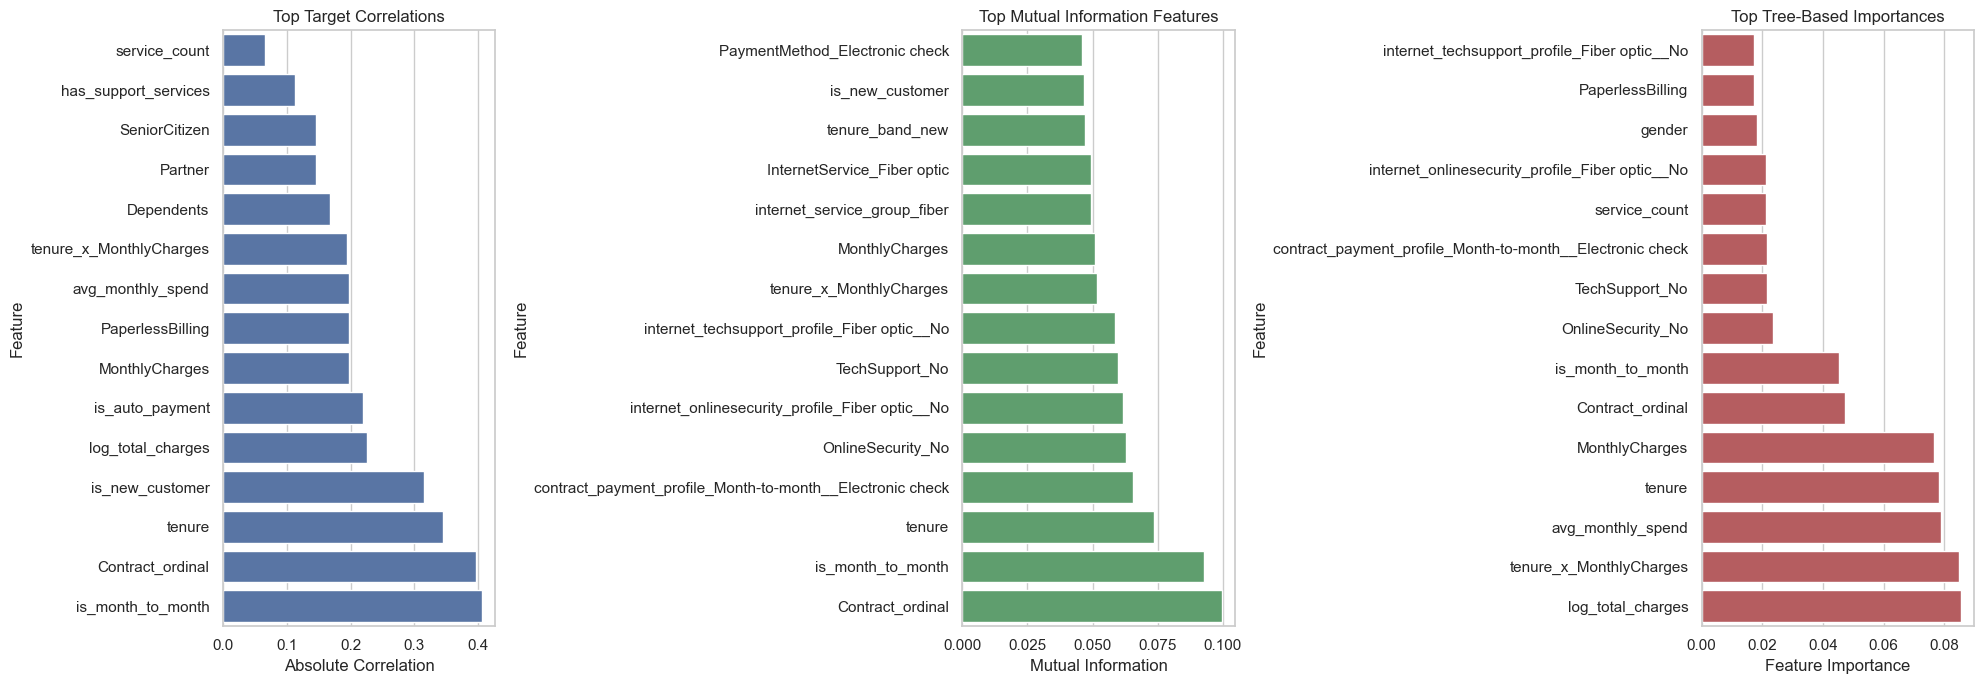

In [143]:
feature_selection_figures_dir = project_root / "reports" / "figures" / "feature_selection"
feature_selection_figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

top_corr = target_relationship_df.head(15).sort_values("abs_pearson_target_corr", ascending=True)
sns.barplot(data=top_corr, x="abs_pearson_target_corr", y="feature", ax=axes[0], color="#4C72B0")
axes[0].set_title("Top Target Correlations")
axes[0].set_xlabel("Absolute Correlation")
axes[0].set_ylabel("Feature")

top_mi = mi_df.head(15).sort_values("mutual_information", ascending=True)
sns.barplot(data=top_mi, x="mutual_information", y="feature", ax=axes[1], color="#55A868")
axes[1].set_title("Top Mutual Information Features")
axes[1].set_xlabel("Mutual Information")
axes[1].set_ylabel("Feature")

top_tree = rf_importance_df.head(15).sort_values("tree_importance", ascending=True)
sns.barplot(data=top_tree, x="tree_importance", y="feature", ax=axes[2], color="#C44E52")
axes[2].set_title("Top Tree-Based Importances")
axes[2].set_xlabel("Feature Importance")
axes[2].set_ylabel("Feature")

plt.tight_layout()
plt.savefig(feature_selection_figures_dir / "feature_selection_rankings.png", dpi=150, bbox_inches="tight")
plt.show()


The ranking plots help compare feature families across different selection perspectives. The target-correlation chart highlights the strongest direct linear signals, the mutual-information chart captures broader non-linear usefulness, and the tree-importance chart shows which features are most valuable to a non-linear ensemble model. Features that appear near the top across multiple plots deserve the highest priority for the final shortlist, while features that rank strongly in only one view should be reviewed more carefully before inclusion.


## Final Selected Features

Summarize the shortlist, dropped features, and features kept under review. This shortlist will feed the modeling notebook.


In [144]:
kept_features = selection_summary_df.loc[selection_summary_df["final_decision"] == "keep", "feature"].tolist()
review_features = selection_summary_df.loc[selection_summary_df["final_decision"] == "review", "feature"].tolist()
dropped_features = selection_summary_df.loc[selection_summary_df["final_decision"] == "drop", "feature"].tolist()

final_feature_decisions_df = pd.DataFrame(
    {
        "keep_features": pd.Series(kept_features, dtype="object"),
        "review_features": pd.Series(review_features, dtype="object"),
        "dropped_features": pd.Series(dropped_features, dtype="object"),
    }
)

# Keep all strong features plus high-value review features that represent important churn signals.
priority_review_features = {
    "is_month_to_month",
    "tenure",
    "MonthlyCharges",
    "log_total_charges",
    "tenure_x_MonthlyCharges",
    "avg_monthly_spend",
    "is_new_customer",
    "service_count",
}
priority_review_prefixes = (
    "contract_payment_profile_",
    "internet_techsupport_profile_",
    "internet_onlinesecurity_profile_",
)

candidate_final_features = [
    feature
    for feature in selection_summary_df["feature"]
    if (
        feature in kept_features
        or feature in priority_review_features
        or any(feature.startswith(prefix) for prefix in priority_review_prefixes)
    )
]

# Remove duplicate representations when a grouped or simpler feature already captures the same information.
manual_drop_features = set()
if {"internet_service_group_fiber", "InternetService_Fiber optic"}.issubset(candidate_final_features):
    manual_drop_features.add("InternetService_Fiber optic")
if {"internet_service_group_dsl", "InternetService_DSL"}.issubset(candidate_final_features):
    manual_drop_features.add("InternetService_DSL")
if {"internet_service_group_no_internet", "InternetService_No"}.issubset(candidate_final_features):
    manual_drop_features.add("InternetService_No")
if {"is_new_customer", "tenure_band_new"}.issubset(candidate_final_features):
    manual_drop_features.add("tenure_band_new")
if {"payment_method_group_electronic_check", "PaymentMethod_Electronic check"}.issubset(candidate_final_features):
    manual_drop_features.add("PaymentMethod_Electronic check")
if {"payment_method_group_manual_check", "PaymentMethod_Mailed check"}.issubset(candidate_final_features):
    manual_drop_features.add("PaymentMethod_Mailed check")

selected_features = [feature for feature in candidate_final_features if feature not in manual_drop_features]
selected_features = list(dict.fromkeys(selected_features))

# Rebuild the full feature matrix without splitting or scaling so the final dataset is ready for modeling.
full_feature_df = df.drop(columns=[target_column]).copy()
full_object_features = full_feature_df.select_dtypes(exclude=["number", "bool"]).columns.tolist()
full_redundant_originals = [
    column for column in full_object_features if f"{column}_ordinal" in full_feature_df.columns
]
full_encoded_categorical_features = [
    column for column in full_object_features if column not in full_redundant_originals
]

full_X = pd.get_dummies(
    full_feature_df.drop(columns=full_redundant_originals, errors="ignore"),
    columns=full_encoded_categorical_features,
    drop_first=False,
    dtype=int,
)

missing_selected_features = [feature for feature in selected_features if feature not in full_X.columns]
if missing_selected_features:
    raise KeyError(f"Selected features missing from full feature matrix: {missing_selected_features}")

final_X = full_X[selected_features].copy()
final_df = final_X.copy()
final_df[target_column] = df[target_column].astype(int)

if final_df.isna().any().any():
    raise ValueError("final_df contains missing values after feature selection.")
if final_df.columns.duplicated().any():
    raise ValueError("final_df contains duplicate columns.")
non_numeric_columns = final_df.select_dtypes(exclude=["number", "bool"]).columns.tolist()
if non_numeric_columns:
    raise TypeError(f"final_df contains non-numeric columns: {non_numeric_columns}")

processed_data_dir = project_root / "data" / "processed"
processed_data_dir.mkdir(parents=True, exist_ok=True)
artifacts_dir = project_root / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)
feature_selection_tables_dir = project_root / "reports" / "tables" / "feature_selection"
feature_selection_tables_dir.mkdir(parents=True, exist_ok=True)

final_dataset_path = processed_data_dir / "telco_churn_selected.csv"
feature_columns_path = artifacts_dir / "feature_columns.json"
final_feature_list_path = feature_selection_tables_dir / "final_selected_feature_list.csv"

final_df.to_csv(final_dataset_path, index=False)
with feature_columns_path.open("w", encoding="utf-8") as f:
    json.dump(selected_features, f, indent=2)
pd.Series(selected_features, name="feature").to_csv(final_feature_list_path, index=False)

final_selection_summary = {
    "features_before_selection": int(X.shape[1]),
    "features_after_selection": len(selected_features),
    "kept_feature_count": len(kept_features),
    "review_feature_count": len(review_features),
    "dropped_feature_count": len(dropped_features),
    "dropped_columns": dropped_features + sorted(manual_drop_features),
    "final_selected_features": selected_features,
    "final_dataset_path": str(final_dataset_path.relative_to(project_root)),
    "feature_columns_path": str(feature_columns_path.relative_to(project_root)),
}

pd.DataFrame([dataset_summary]).to_csv(feature_selection_tables_dir / "dataset_summary.csv", index=False)
pd.DataFrame([sanity_summary]).to_csv(feature_selection_tables_dir / "data_sanity_summary.csv", index=False)
dtype_summary.to_csv(feature_selection_tables_dir / "dtype_summary.csv", index=False)
feature_type_summary.to_csv(feature_selection_tables_dir / "feature_type_summary.csv", index=False)
pd.DataFrame([low_information_summary]).to_csv(feature_selection_tables_dir / "low_information_summary.csv", index=False)
target_relationship_df.to_csv(feature_selection_tables_dir / "target_relationship_review.csv", index=False)
high_corr_pairs_df.to_csv(feature_selection_tables_dir / "redundancy_review.csv", index=False)
mi_df.to_csv(feature_selection_tables_dir / "mutual_information_ranking.csv", index=False)
rf_importance_df.to_csv(feature_selection_tables_dir / "tree_feature_importance.csv", index=False)
vif_df.to_csv(feature_selection_tables_dir / "vif_review.csv", index=False)
pd.DataFrame([{"vif_summary_note": vif_summary_note}]).to_csv(feature_selection_tables_dir / "vif_summary_note.csv", index=False)
pd.DataFrame([model_selection_summary]).to_csv(feature_selection_tables_dir / "model_selection_summary.csv", index=False)
l1_selection_df.to_csv(feature_selection_tables_dir / "l1_selection.csv", index=False)
rfe_df.to_csv(feature_selection_tables_dir / "rfe_selection.csv", index=False)
select_from_model_df.to_csv(feature_selection_tables_dir / "select_from_model_selection.csv", index=False)
selection_summary_df.to_csv(feature_selection_tables_dir / "selection_summary.csv", index=False)
final_feature_decisions_df.to_csv(feature_selection_tables_dir / "final_feature_decisions.csv", index=False)
pd.DataFrame([final_selection_summary]).to_csv(feature_selection_tables_dir / "final_selection_summary.csv", index=False)

print(f"Features before selection: {X.shape[1]}")
print(f"Features after selection: {len(selected_features)}")
print("Dropped columns:", dropped_features + sorted(manual_drop_features))
print("Final selected features:", selected_features)

final_selection_summary


Features before selection: 33
Features after selection: 53
Dropped columns: ['InternetService_DSL', 'contract_payment_profile_One year__Bank transfer (automatic)', 'contract_payment_profile_One year__Credit card (automatic)', 'PaymentMethod_Mailed check', 'payment_method_group_manual_check', 'contract_payment_profile_One year__Electronic check', 'contract_payment_profile_Month-to-month__Bank transfer (automatic)', 'PhoneService', 'MultipleLines_No phone service', 'PaymentMethod_Bank transfer (automatic)', 'contract_payment_profile_One year__Mailed check', 'contract_payment_profile_Two year__Electronic check', 'contract_payment_profile_Month-to-month__Mailed check', 'internet_onlinesecurity_profile_Fiber optic__Yes', 'contract_payment_profile_Month-to-month__Credit card (automatic)', 'internet_techsupport_profile_Fiber optic__Yes', 'internet_techsupport_profile_DSL__No', 'internet_onlinesecurity_profile_DSL__No', 'InternetService_Fiber optic']
Final selected features: ['contract_payment

{'features_before_selection': 33,
 'features_after_selection': 53,
 'kept_feature_count': 32,
 'review_feature_count': 27,
 'dropped_feature_count': 18,
 'dropped_columns': ['InternetService_DSL',
  'contract_payment_profile_One year__Bank transfer (automatic)',
  'contract_payment_profile_One year__Credit card (automatic)',
  'PaymentMethod_Mailed check',
  'payment_method_group_manual_check',
  'contract_payment_profile_One year__Electronic check',
  'contract_payment_profile_Month-to-month__Bank transfer (automatic)',
  'PhoneService',
  'MultipleLines_No phone service',
  'PaymentMethod_Bank transfer (automatic)',
  'contract_payment_profile_One year__Mailed check',
  'contract_payment_profile_Two year__Electronic check',
  'contract_payment_profile_Month-to-month__Mailed check',
  'internet_onlinesecurity_profile_Fiber optic__Yes',
  'contract_payment_profile_Month-to-month__Credit card (automatic)',
  'internet_techsupport_profile_Fiber optic__Yes',
  'internet_techsupport_profil

## Closing Notes

This notebook narrows the engineered feature space into a more defensible shortlist for downstream modeling. The strongest candidates are the features that remain important across multiple views, especially contract, tenure, spend, and support-related signals. Features marked `review` should not be discarded immediately, but they should be tested carefully in the modeling notebook alongside redundancy and multicollinearity considerations. The next step is to move into modeling with the shortlisted features and compare model performance using a leakage-safe train/test workflow.
